In [17]:
!pip install mysql-connector-python pandas matplotlib seaborn scikit-learn

In [18]:
import mysql.connector            
import pandas as pd               
import matplotlib.pyplot as plt   
import seaborn as sns            
import warnings
warnings.filterwarnings('ignore')


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
with mysql.connector.connect(
    host="localhost",
    user="DB User",
    password="DB Password",
    database="DB Name"
) as conn:
    df = pd.read_sql("SELECT * FROM customers", conn)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_clean
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,No,593.30
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,No,542.40
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,280.85
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,1237.85
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,Yes,267.40


In [20]:
# Convert Yes/No to 1/0
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Ensure TotalCharges_clean is numeric and replace invalid values with 0
df['TotalCharges_clean'] = pd.to_numeric(
    df['TotalCharges_clean'],
    errors='coerce'
).fillna(0)

print("Churn value counts:")
print(df['Churn'].value_counts())

print(f"\nOverall churn rate: {df['Churn_binary'].mean():.2%}")

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


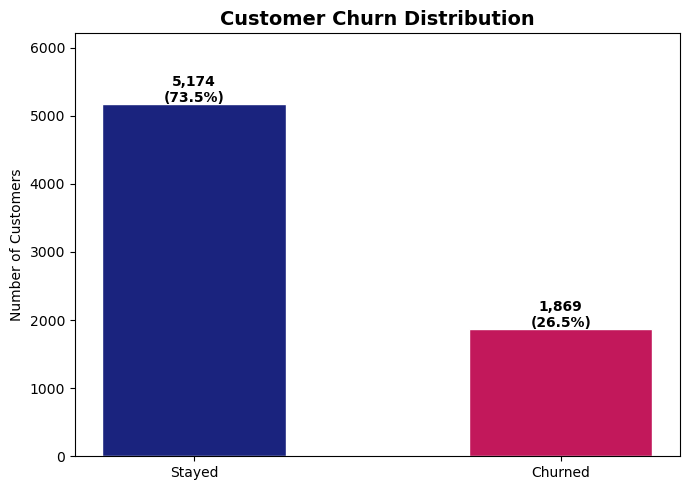

In [22]:
BRAND_PINK = '#C2185B'   # dark pink
BRAND_BLUE = '#1A237E'   # dark blue

churn_counts = df['Churn'].value_counts().reindex(['No', 'Yes'])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Stayed', 'Churned'],
    churn_counts,
    color=[BRAND_BLUE, BRAND_PINK],
    edgecolor='white',
    width=0.5
)

for bar, count in zip(bars, churn_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{count:,}\n({count/len(df):.1%})',
        ha='center',
        fontweight='bold'
    )

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.ylim(0, churn_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

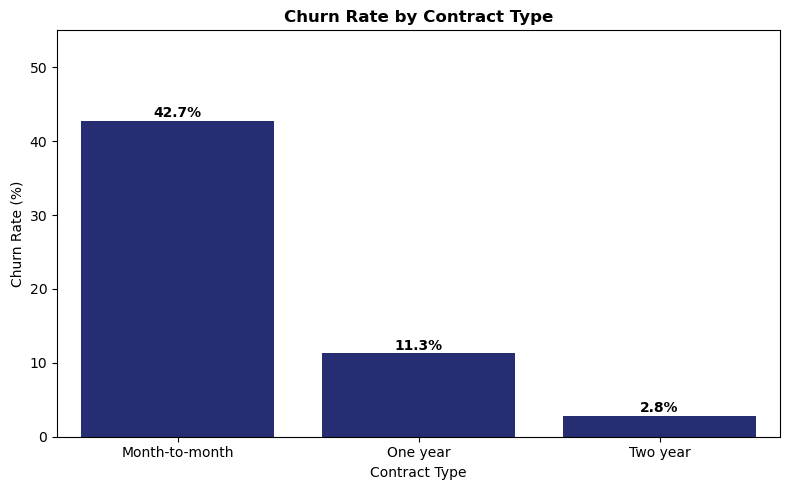

In [23]:
BRAND_BLUE = '#1A237E'
BRAND_PINK = '#C2185B'

contract_churn = (
    df.groupby('Contract')['Churn_binary']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate_pct')
    .sort_values('churn_rate_pct', ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_churn,
    x='Contract',
    y='churn_rate_pct',
    color=BRAND_BLUE
)

for p, value in zip(ax.patches, contract_churn['churn_rate_pct']):
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.5,
        f"{value:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.title('Churn Rate by Contract Type', fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)

plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

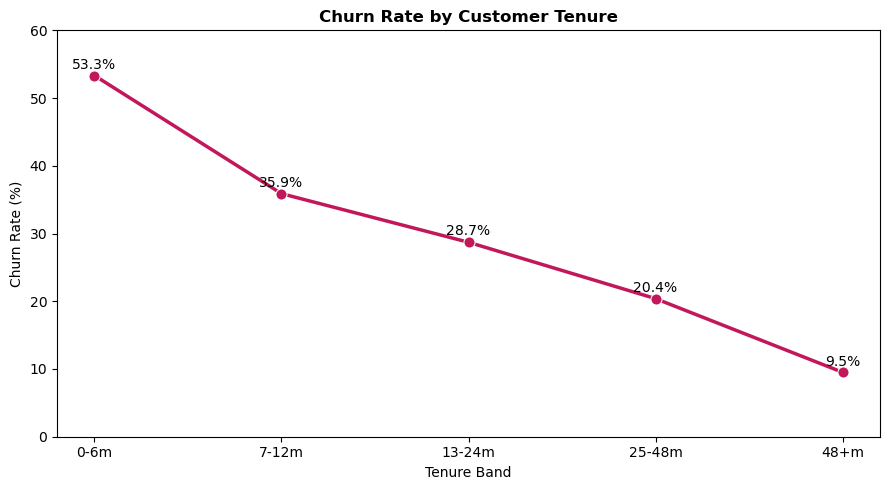

In [24]:
BRAND_BLUE = '#1A237E'
BRAND_PINK = '#C2185B'

df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6m', '7-12m', '13-24m', '25-48m', '48+m']
)

tenure_churn = (
    df.groupby('tenure_band', observed=True)['Churn_binary']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate_pct')
)

plt.figure(figsize=(9, 5))

ax = sns.lineplot(
    data=tenure_churn,
    x='tenure_band',
    y='churn_rate_pct',
    marker='o',
    color=BRAND_PINK,
    linewidth=2.5,
    markersize=8
)

for _, row in tenure_churn.iterrows():
    ax.text(
        row['tenure_band'],
        row['churn_rate_pct'] + 1,
        f"{row['churn_rate_pct']:.1f}%",
        ha='center',
        fontsize=10
    )

plt.title('Churn Rate by Customer Tenure', fontweight='bold')
plt.xlabel('Tenure Band')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 60)

plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

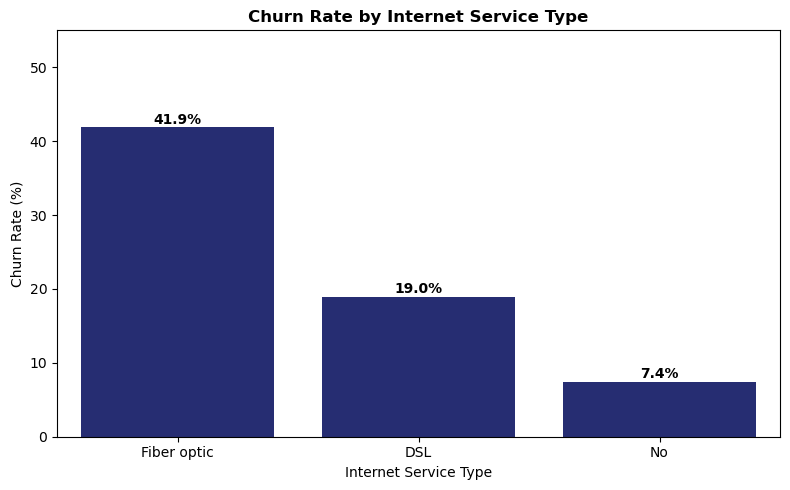

In [25]:
BRAND_BLUE = '#1A237E'
BRAND_PINK = '#C2185B'

internet_churn = (
    df.groupby('InternetService', observed=True)['Churn_binary']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate_pct')
    .sort_values('churn_rate_pct', ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=internet_churn,
    x='InternetService',
    y='churn_rate_pct',
    color=BRAND_BLUE
)

for p, value in zip(ax.patches, internet_churn['churn_rate_pct']):
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.5,
        f"{value:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.title('Churn Rate by Internet Service Type', fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 55)

plt.tight_layout()
plt.savefig('churn_by_internet.png', dpi=150)
plt.show()

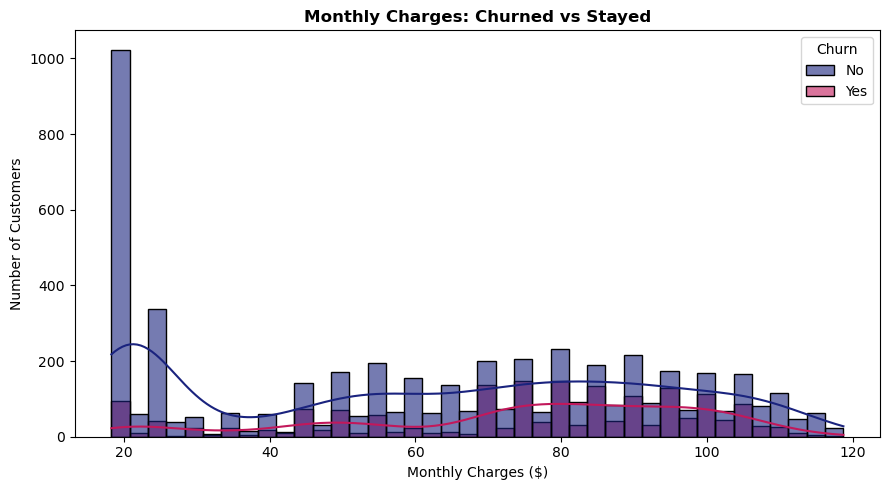

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

In [26]:
BRAND_BLUE = '#1A237E'
BRAND_PINK = '#C2185B'

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=40,
    kde=True,
    palette={'No': BRAND_BLUE, 'Yes': BRAND_PINK},
    alpha=0.6
)

plt.title('Monthly Charges: Churned vs Stayed', fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('monthly_charges_distribution.png', dpi=150)
plt.show()

df.groupby('Churn')['MonthlyCharges'].mean().round(2)

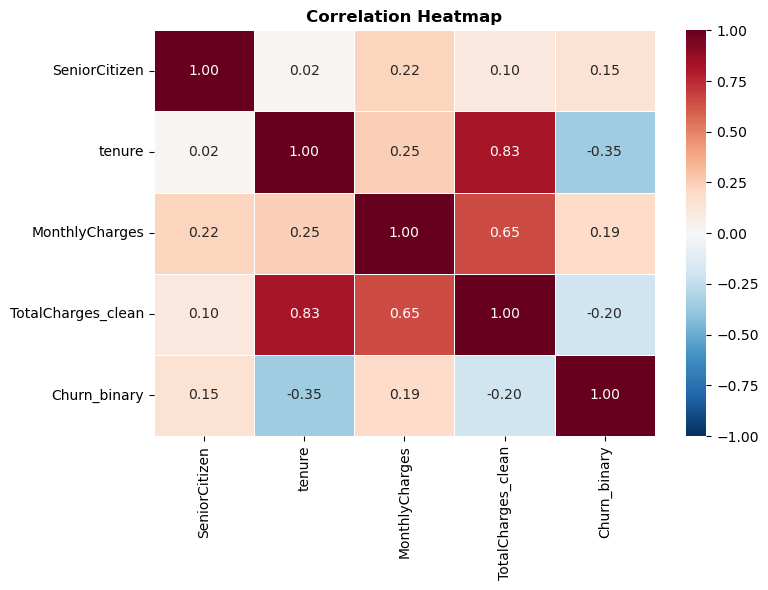

In [27]:
BRAND_BLUE = '#1A237E'
BRAND_PINK = '#C2185B'

numeric_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges_clean',
    'Churn_binary'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',   # blue = negative, red = positive 
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [28]:
# Features used for prediction
features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges_clean',
    'Contract', 'PaymentMethod', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

df_model = df[features + ['Churn_binary']].copy()

# One-hot encode categorical variables
categorical_cols = [
    'Contract', 'PaymentMethod', 'InternetService',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Split features and target
X = df_model.drop('Churn_binary', axis=1)
y = df_model['Churn_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} rows")
print(f"Test set size:     {len(X_test)} rows")

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel training complete.")

Training set size: 5634 rows
Test set size:     1409 rows

Model training complete.


=== Model Performance ===

              precision    recall  f1-score   support

      Stayed       0.82      0.90      0.86      1036
     Churned       0.61      0.46      0.52       373

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



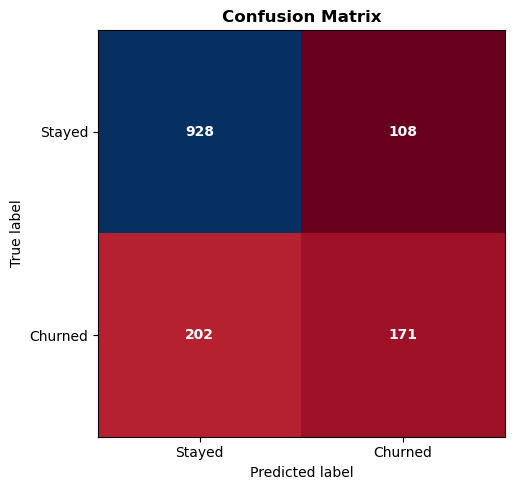

In [30]:
y_pred = model.predict(X_test)

print("=== Model Performance ===\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Stayed', 'Churned']
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)

disp.plot(ax=ax, colorbar=False, cmap='RdBu')

for text in ax.texts:
    text.set_color('white')
    text.set_fontweight('bold')

plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

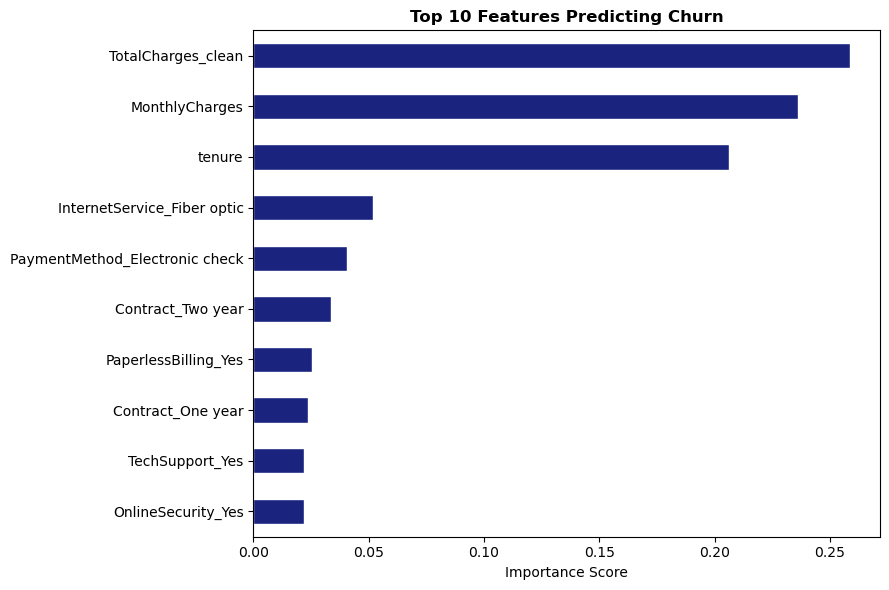


Top 10 churn predictors:
TotalCharges_clean                0.2587
MonthlyCharges                    0.2362
tenure                            0.2062
InternetService_Fiber optic       0.0518
PaymentMethod_Electronic check    0.0408
Contract_Two year                 0.0338
PaperlessBilling_Yes              0.0256
Contract_One year                 0.0236
TechSupport_Yes                   0.0220
OnlineSecurity_Yes                0.0219
dtype: float64


In [31]:
importances = pd.Series(model.feature_importances_, index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))

top10.sort_values().plot(
    kind='barh',
    color='#1A237E',   # BRAND_BLUE
    edgecolor='white'
)

plt.title('Top 10 Features Predicting Churn', fontweight='bold')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 churn predictors:")
print(top10.sort_values(ascending=False).round(4))

In [32]:
# Active (non-churned) customers
active = df[df['Churn'] == 'No'].copy()

# One-hot encode using same feature set as training
active_model = pd.get_dummies(
    active[features],
    columns=[
        'Contract', 'PaymentMethod', 'InternetService',
        'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
    ],
    drop_first=True
)

# Align columns with training data
active_model = active_model.reindex(columns=X.columns, fill_value=0)

# Predict churn probability
active['churn_probability'] = model.predict_proba(active_model)[:, 1].round(4)

# High-risk customers
high_risk = active.loc[
    active['churn_probability'] > 0.6,
    [
        'customerID', 'Contract', 'tenure', 'InternetService',
        'MonthlyCharges', 'PaymentMethod', 'churn_probability'
    ]
].sort_values('churn_probability', ascending=False)

# Business summary
total = len(active)
risk_count = len(high_risk)
monthly_risk = high_risk['MonthlyCharges'].sum()

print(f"Total active customers:        {total:,}")
print(f"High risk customers (>60%):    {risk_count:,}")
print(f"Monthly revenue at risk:       ${monthly_risk:,.2f}")
print(f"Annual revenue at risk:        ${monthly_risk * 12:,.2f}")

# Export for Power BI
high_risk.to_csv('high_risk_customers.csv', index=False)

print("\nExported to high_risk_customers.csv")

high_risk.head(10)

Total active customers:        5,174
High risk customers (>60%):    76
Monthly revenue at risk:       $5,487.95
Annual revenue at risk:        $65,855.40

Exported to high_risk_customers.csv


,customerID,Contract,tenure,InternetService,MonthlyCharges,PaymentMethod,churn_probability
17,0021-IKXGC,Month-to-month,1,Fiber optic,72.10,Electronic check,1.00
2726,3878-AVSOQ,Month-to-month,1,Fiber optic,71.25,Electronic check,0.99
1545,2254-DLXRI,Month-to-month,1,Fiber optic,79.15,Mailed check,0.99
3478,4927-WWOOZ,Month-to-month,2,Fiber optic,91.45,Electronic check,0.96
1550,2262-SLNVK,Month-to-month,1,Fiber optic,70.10,Electronic check,0.96
2351,3370-HXOPH,Month-to-month,3,Fiber optic,76.10,Electronic check,0.93
3352,4781-ZXYGU,Month-to-month,1,No,20.15,Bank transfer (automatic),0.92
6151,8714-CTZJW,Month-to-month,4,Fiber optic,82.85,Credit card (automatic),0.91
4951,6969-MVBAI,Month-to-month,9,Fiber optic,90.10,Electronic check,0.91
4564,6435-SRWBJ,Month-to-month,5,Fiber optic,82.75,Electronic check,0.91
